In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [68]:
df= pd.read_csv('titanic_dataset.csv', usecols=['Age','Fare','Survived'])

In [103]:
df.sample(5)

,FireplaceQu,GarageQual,SalePrice
233,NaN,TA,128200
498,NaN,TA,130000
1226,Gd,TA,214000
589,NaN,TA,79500
777,Fa,TA,142500


In [70]:
df.isnull().mean() *100

Survived     0.000000
Age         20.574163
Fare         0.239234
dtype: float64

In [71]:
df = df.dropna(subset=['Fare'])

In [72]:
df.isnull().mean() *100

Survived     0.000000
Age         20.623501
Fare         0.000000
dtype: float64

In [73]:
X = df.drop('Survived',axis=1)
y= df.Survived

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.2)

In [75]:
#coping same value
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed']= X_test['Age']

In [76]:
# X_train['Age_imputed'][X_train['Age_imputed'].isnull()] -> to take out the null value only
# like df[df['age']> 18]

no_of_null = X_train['Age'].isnull().sum()
random_samples = X_train['Age'].dropna().sample(no_of_null).values
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = random_samples

In [77]:
X_train.sample(5)

,Age,Fare,Age_imputed
326,12.0,39.0000,12.0
339,NaN,7.2292,23.0
264,30.0,12.7375,30.0
388,21.0,7.7500,21.0
262,29.0,23.0000,29.0


In [78]:
no_of_null_test = X_test['Age'].isnull().sum()
random_samples_test = X_test['Age'].dropna().sample(no_of_null_test).values
X_test.loc[X_test['Age_imputed'].isnull(),'Age_imputed']=random_samples_test

In [79]:
X_train.isnull().sum()

Age            73
Fare            0
Age_imputed     0
dtype: int64

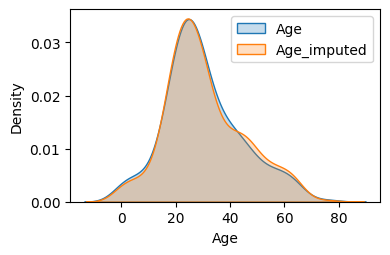

In [80]:
plt.figure(figsize=(4,2.5))
sns.kdeplot(X_train['Age'],fill= True, label='Age')
sns.kdeplot(X_train['Age_imputed'],fill=True, label='Age_imputed')
plt.legend()
plt.show()

In [81]:
print('Age Variance:', X_train['Age'].var())
print('Age_imputed Variance', X_train['Age_imputed'].var())

Age Variance: 200.70558791060293
Age_imputed Variance 205.021027549839


In [82]:
X_train.cov()

,Age,Fare,Age_imputed
Age,200.705588,274.167395,200.705588
Fare,274.167395,2792.158209,203.552312
Age_imputed,200.705588,203.552312,205.021028


In [83]:
#Covariance with other columns of Age , Age_imputed has changed

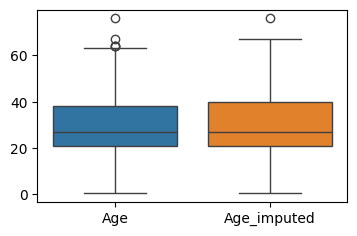

In [84]:
plt.figure(figsize=(4,2.5))
sns.boxplot(X_train[['Age','Age_imputed']])
plt.show()

In [85]:
#no much change in outliers

In [86]:
#here, the random number will be generated for fare , if we enter age, then reload and enter again.
#do change in random_state
# sampled_value = X_train['Age'].dropna().sample(1,random_state=int(observation['Fare']))

#### For Categorical Data

In [87]:
df= pd.read_csv('house_dataset.csv', usecols=['GarageQual','FireplaceQu','SalePrice'])
df.sample(5)

,FireplaceQu,GarageQual,SalePrice
265,TA,TA,175500
100,TA,TA,205000
541,TA,TA,248000
1064,Po,TA,154000
335,Gd,TA,228950


In [88]:
df.isnull().mean() *100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [89]:
X =df
y= df['SalePrice']

In [90]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=2)

In [94]:
X_train['GarageQual_imputed']= X_train['GarageQual']
X_test['GarageQual_imputed']= X_test['GarageQual']

X_train['FireplaceQu_imputed']= X_train['FireplaceQu']
X_test['FireplaceQu_imputed']=X_test['FireplaceQu']


In [95]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1022,NaN,Fa,87000,Fa,NaN
3,Gd,TA,140000,TA,Gd
214,NaN,TA,161750,TA,NaN
896,NaN,TA,106500,TA,NaN
973,NaN,TA,182000,TA,NaN


In [96]:
num_of_null_train1 = X_train['GarageQual'].isnull().sum()
random_samples_train1 =  X_train['GarageQual'].dropna().sample(num_of_null_train1).values
X_train.loc[X_train['GarageQual_imputed'].isnull(),'GarageQual_imputed'] = random_samples_train1

num_of_null_test1 = X_test['GarageQual'].isnull().sum()
random_samples_test1 = X_test['GarageQual'].dropna().sample(num_of_null_test1).values
X_test.loc[X_test['GarageQual_imputed'].isnull(),'GarageQual_imputed'] = random_samples_test1

num_of_null_train2 = X_train['FireplaceQu'].isnull().sum()
random_samples_train2 =  X_train['FireplaceQu'].dropna().sample(num_of_null_train2).values
X_train.loc[X_train['FireplaceQu_imputed'].isnull(),'FireplaceQu_imputed'] = random_samples_train2

num_of_null_test2 = X_test['FireplaceQu'].isnull().sum()
random_samples_test2 = X_test['FireplaceQu'].dropna().sample(num_of_null_test2).values
X_test.loc[X_test['FireplaceQu_imputed'].isnull(),'FireplaceQu_imputed'] = random_samples_test2

In [110]:
#checking the frequency distribution of the data before imputation and after imputation 
# better way is below graph

temp=pd.concat(
    [
        X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
        X_train['GarageQual_imputed'].value_counts()/ len(X_train)
    ],
    axis=1
)
temp.columns = ['original','imputed']
temp

,original,imputed
TA,0.951043,0.952911
Fa,0.037171,0.035959
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [111]:
temp2= pd.concat([
    X_train['FireplaceQu'].value_counts()/ len(X_train['FireplaceQu'].dropna()),
    X_train['FireplaceQu_imputed'].value_counts()/ len(X_train)
],axis=1)
temp2.columns=['Original','Imputed']
temp2

,Original,Imputed
Gd,0.494272,0.495719
TA,0.412439,0.413527
Fa,0.040917,0.040240
Po,0.027823,0.026541
Ex,0.024550,0.023973


In [112]:
len(X_train)

1168

In [113]:
X_train.isnull().sum()

FireplaceQu            557
GarageQual              65
SalePrice                0
GarageQual_imputed       0
FireplaceQu_imputed      0
dtype: int64

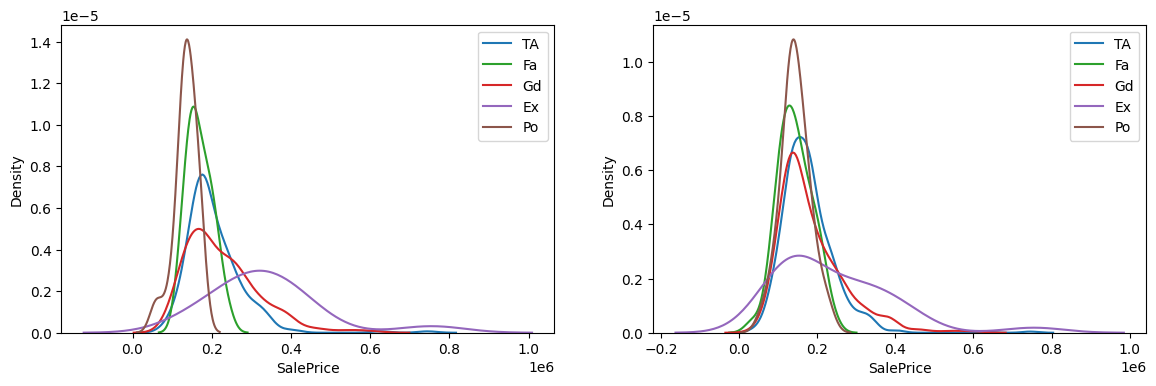

In [121]:
#better to check than frequency distribution

plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
unique_value = X_train['FireplaceQu'].unique()
for category in unique_value:
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'], label=category)
plt.legend()

plt.subplot(1,2,2)
unique_value_after = X_train['FireplaceQu_imputed'].unique()
for category in unique_value:
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'], label=category)

plt.legend()
plt.show()

In [ ]:
# distribution has been changed , coz value missing